In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob  # is used for pattern matching and filename expansion.
import cv2

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

import time
!pip install python-docx
from docx import Document
from docx.shared import Inches

from google.colab import files

!pip install openpyxl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 2.1 MB/s eta 0:00:00


In [ ]:
### ---- Importing the dataset from kaggle --- ###

# Install kaggle
! pip install kaggle

# Monut google drive in colab
from google.colab import drive
drive.mount('/content/drive')

# make a new folder in the root directory
! mkdir ~/.kaggle

# Copy the kaggle-json-file (Token) into the .kaggle-folder
! cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/

# Change file permission
! chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset
! kaggle datasets download tawsifurrahman/covid19-radiography-database

! unzip covid19-radiography-database.zip

Streaming output truncated to the last 5000 lines.
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png  
 

In [ ]:
### ---- Generating list of file names --- ###

# Generating lists containing all file paths for each class
cxr_covid = glob('/content/COVID-19_Radiography_Dataset/COVID/images/*.png')
cxr_lung_opacity = glob('/content/COVID-19_Radiography_Dataset/Lung_Opacity/images/*.png')
cxr_normal = glob('/content/COVID-19_Radiography_Dataset/Normal/images/*.png')
cxr_viral_pneumonia = glob('/content/COVID-19_Radiography_Dataset/Viral Pneumonia/images/*.png')

# Concatenating all file paths into a single list
cxr_all = cxr_covid + cxr_lung_opacity + cxr_normal + cxr_viral_pneumonia

# Check the content and the length of the resulting list (Expected: list of file paths, a length of 21165 images)
print(cxr_all, '\n',len(cxr_all))

['/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2277.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-795.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-3492.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-154.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-155.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-1303.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2917.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2468.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2028.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-134.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-3012.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-1394.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2659.png', '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-279.png', '/content/COVID-19_Radiography_Dataset

In [ ]:
### --- Model performance for different image sizes --- ###

# Creating lists to store results calculated below
img_size = []
train_acc = []
val_acc = []
train_loss =[]
val_loss =[]
accuracy_list = []
f1_scores_covid = []
f1_score_opacity = []
f1_score_normal = []
f1_score_pneumonia = []
execution_times = []

# Set image sizes that should be analyzed
image_sizes = [299]

# Loop through the different image sizes
for size in image_sizes:
  img_size.append(size)

  ### --- Creating an array of images --- ###

  # Create empty lists
  X = []
  y = []

  # Set the image size (resize for the initial trials)
  width = size
  height = size

  # Loading images into a 3 dimensional numpy array
  for img_path in cxr_all:
      image = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
      image = cv2.resize(image, (width, height))
      X.append(image)
      # Extract case name
      img_case = img_path.split('.')[0].split('/')[3]
      y.append(img_case)

  # Convert list to numpy arrays
  X = np.array(X)
  y = np.array(y)


  ### --- Image preprocessing --- ###

  # Normalize input data to a range between 0-1
  X = X.astype(float)
  X = X/255

  # Encode classes as numbers (LabelEncoder)
  le = LabelEncoder()
  y = le.fit_transform(y)

  # Split the data set into test and train data
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

  # Transform the classe into binary categories (one-hot-encoding, better for the DNN as it does not imply any order in the classes (eg. 3>1))
  y_train = to_categorical(y_train)
  y_test = to_categorical(y_test)

  # Flatten the image that the dense neuronal network can work with it (DO NOT DO THIS STEP FOR CNNs)
  X_train = X_train.reshape(-1, width*height)
  X_test = X_test.reshape(-1, width*height)

  # Standardize the data
  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)


  ### --- Neuronal network --- ###

  # Define the architecture of the neural network
  inputs = Input(shape = (width*height,), name = "Input")

  dense1 = Dense(units = int((width*height)/4), activation = 'relu', name = 'first_layer')
  dense2 = Dense(units = int((width*height)/16), activation = 'relu', name = 'second_layer')
  dense3 = Dense(units = int((width*height/64)), activation = 'relu', name = 'third_layer')
  dense4 = Dense(units = 256, activation = 'relu', name = 'fourth_layer')
  dense5 = Dense(units = 128, activation = 'relu', name = 'fifth_layer')
  dense6 = Dense(units = 64, activation = 'relu', name = 'sixth_layer')
  dense7 = Dense(units = 4, activation = 'softmax', name = 'seventh_layer') # numer of classes = number of units

  x=dense1(inputs)
  x=dense2(x)
  x=dense3(x)
  x=dense4(x)
  x=dense5(x)
  x=dense6(x)
  outputs=dense7(x)

  model = Model(inputs = inputs, outputs = outputs)

  # Print the model summary
  model.summary()

  # Compile the model
  model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

  # Define parameters
  epochs = 20
  batch_size = 200
  validation_split = 0.2

  # Record starting time of training and prediction
  start_time = time.time()

  # Train the model
  training_history = model.fit(X_train, y_train,
                    epochs = epochs,
                    batch_size = batch_size,
                    validation_split = validation_split)

  # Predict probabilities to belong to the different classes
  test_pred = model.predict(X_test)

  # Record the end time
  end_time = time.time()
  # Calculate the execution time
  execution_time = (end_time - start_time)/60
  # Add execution time to the list
  execution_times.append(execution_time)

  # Predict classes
  y_pred_class = test_pred.argmax(axis = 1)
  y_test_class = y_test.argmax(axis = 1)


  ### --- Evaluating the performance --- ###

  # Record accuracy and loss
  train_acc.append(training_history.history['accuracy'])
  val_acc.append(training_history.history['val_accuracy'])
  train_loss.append(training_history.history["loss"])
  val_loss.append(training_history.history["val_loss"])

  loss, accuracy = model.evaluate(X_test, y_test)
  accuracy_list.append(accuracy)

  # Classification report
  cl_report = classification_report(y_test_class, y_pred_class, output_dict=True)
  cl_report_df = pd.DataFrame(cl_report).transpose()
  f1_scores_covid.append(cl_report_df.iloc[le.transform(['COVID'])[0]]['f1-score'])
  f1_score_opacity.append(cl_report_df.iloc[le.transform(['Lung_Opacity'])[0]]['f1-score'])
  f1_score_normal.append(cl_report_df.iloc[le.transform(['Normal'])[0]]['f1-score'])
  f1_score_pneumonia.append(cl_report_df.iloc[le.transform(['Viral Pneumonia'])[0]]['f1-score'])


# Create a DataFrame with the results and display it
results = pd.DataFrame({'Image size' : img_size,
                        'Accuracy' : accuracy_list,
                        # 'Training accuracy' : train_acc,
                        # 'Validation/test accuracy' : val_acc,
                        # 'Train loss' : train_loss,
                        # 'Test loss' : val_loss,
                        'f1 score COVID' :  f1_scores_covid,
                        'f1 score Lung opacity' : f1_score_opacity,
                        'f1 score normal' : f1_score_normal,
                        'f1 score Viral pneumonia' : f1_score_pneumonia,
                        'Execution time [min]' : execution_times})
display(results)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 89401)]           0         
                                                                 
 first_layer (Dense)         (None, 22350)             1998134700
                                                                 
 second_layer (Dense)        (None, 5587)              124875037 
                                                                 
 third_layer (Dense)         (None, 1396)              7800848   
                                                                 
 fourth_layer (Dense)        (None, 256)               357632    
                                                                 
 fifth_layer (Dense)         (None, 128)               32896     
                                                                 
 sixth_layer (Dense)         (None, 64)                8256

,Image size,Accuracy,f1 score COVID,f1 score Lung opacity,f1 score normal,f1 score Viral pneumonia,Execution time [min]
0,299,0.837467,0.810382,0.789809,0.866364,0.890943,181.787534


In [ ]:
# Save the DataFrame as a CSV file
results.to_excel(f'/content/DenseNeuronalNetworks_ImageSizes.xlsx', index=False)

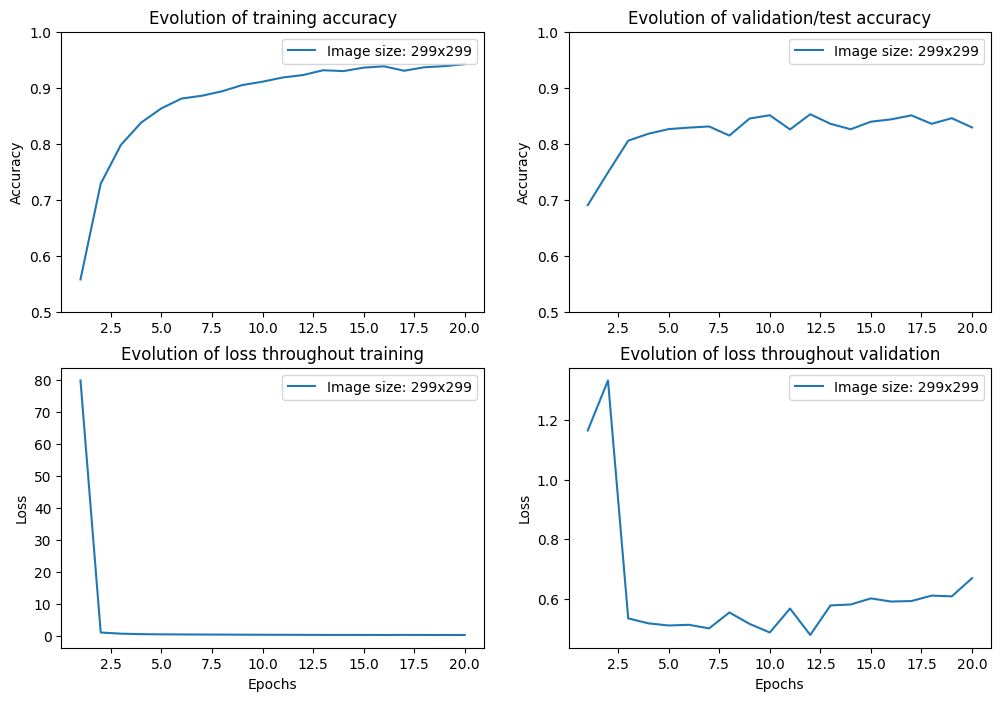

In [ ]:
### --- Plot performance data --- ###

# Create a large figure for 4 subplots
plt.figure(figsize=(12,8))

# Generation of subplot 1
plt.subplot(221)
for i in range(len(image_sizes)):
  plt.plot(np.arange(1,21,1), train_acc[i], label= f'Image size: {image_sizes[i]}x{image_sizes[i]}')
plt.xlabel('')
plt.ylabel('Accuracy')
plt.title('Evolution of training accuracy')
plt.legend()
plt.ylim(0.5,1)

# Generation of subplot 2
plt.subplot(222)
for i in range(len(image_sizes)):
  plt.plot(np.arange(1,21,1), val_acc[i], label= f'Image size: {image_sizes[i]}x{image_sizes[i]}')
plt.xlabel('')
plt.ylabel('Accuracy')
plt.title('Evolution of validation/test accuracy')
plt.legend()
plt.ylim(0.5,1)

# Generation of subplot 3
plt.subplot(223)
for i in range(len(image_sizes)):
  plt.plot(np.arange(1,21,1), train_loss[i], label= f'Image size: {image_sizes[i]}x{image_sizes[i]}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Evolution of loss throughout training')
plt.legend()
# plt.ylim(0,6)

# Generation of subplot 4
plt.subplot(224)
for i in range(len(image_sizes)):
  plt.plot(np.arange(1,21,1), val_loss[i], label= f'Image size: {image_sizes[i]}x{image_sizes[i]}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Evolution of loss throughout validation')
plt.legend()
# plt.ylim(0, 6)

# Save image as .png
plt.savefig(f'/content/Evolution of accuracy and loss', bbox_inches = 'tight')


In [ ]:
print(f"Label 0 is: {le.inverse_transform([0])}")
print(f"Label 1 is: {le.inverse_transform([1])}")
print(f"Label 2 is: {le.inverse_transform([2])}")
print(f"Label 3 is: {le.inverse_transform([3])}")

Label 0 is: ['COVID']
Label 1 is: ['Lung_Opacity']
Label 2 is: ['Normal']
Label 3 is: ['Viral Pneumonia']


In [ ]:
# Display the confusion matrix
display(pd.crosstab(y_test_class, y_pred_class, rownames = ['real classification'], colnames = ['predicted classification']))


predicted classification,0,1,2,3
real classification,,,,
0,562,49,79,11
1,59,930,254,3
2,62,126,1812,24
3,3,4,14,241
